In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 1 — Colab setup: install deps + mount Drive
# ══════════════════════════════════════════════════════════════════════════════
import sys
import numpy as np

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # Install pinned dependencies
    import subprocess
    subprocess.run([
        sys.executable, "-m", "pip", "install", "-q",
        "kloppy==3.18.0",
        "pyarrow==22.0.0",
        "pandas==2.2.3",
        "numpy==1.26.4",
        "lxml==5.3.0",
        "scikit-learn==1.6.1",
        "scipy==1.13.1", # Added to ensure compatibility with numpy 2.1.3
    ], check=True)

    # Mount Google Drive
    from google.colab import drive
    drive.mount("/content/drive")

    base_root = "/content/drive/MyDrive/Superliga_2024_2025_ALL_SEASON"

else:
    print("Not running in Colab — using local paths.")

    # Example local fallback
    base_root = "./Superliga_2024_2025_ALL_SEASON"

# Define paths (works in both environments)
results_path = f"{base_root}/F1_Results_Feed"
squads_path = f"{base_root}/F40_Squads_Feed"
matchfeeds_path = f"{base_root}/Matchfeeds"

print("Paths ready:")
print("Results:", results_path)
print("Squads:", squads_path)
print("Matchfeeds:", matchfeeds_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Paths ready:
Results: /content/drive/MyDrive/Superliga_2024_2025_ALL_SEASON/F1_Results_Feed
Squads: /content/drive/MyDrive/Superliga_2024_2025_ALL_SEASON/F40_Squads_Feed
Matchfeeds: /content/drive/MyDrive/Superliga_2024_2025_ALL_SEASON/Matchfeeds


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 2 — Imports
# ══════════════════════════════════════════════════════════════════════════════
import gc
import json
import time as _time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from lxml import etree
from scipy.spatial import ConvexHull

from kloppy import secondspectrum

pd.set_option("display.max_columns", None)
warnings.filterwarnings("ignore", category=FutureWarning)

print("Imports ready.")

Imports ready.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 3 — Paths (Colab-aware output directories)
# ══════════════════════════════════════════════════════════════════════════════
# We now reuse `base_root` and `matchfeeds_path` defined cleanly in Cell 1!
from pathlib import Path

DATA_ROOT = Path(matchfeeds_path)
OUTPUT_ROOT = Path(base_root)

EXPECTED_FULL_MATCH_COUNT = 192

if not DATA_ROOT.exists():
    raise FileNotFoundError(f"DATA_ROOT does not exist: {DATA_ROOT}. Please check your Drive mounting.")

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
PER_MATCH_DIR = OUTPUT_ROOT / "press_df_v2_per_match"
PER_MATCH_DIR.mkdir(parents=True, exist_ok=True)

FINAL_PARQUET_PATH = OUTPUT_ROOT / "press_df_v2_FINAL.parquet"

print(f"DATA_ROOT       = {DATA_ROOT}")
print(f"PER_MATCH_DIR   = {PER_MATCH_DIR}")
print(f"FINAL_PARQUET   = {FINAL_PARQUET_PATH}")

DATA_ROOT       = /content/drive/MyDrive/Superliga_2024_2025_ALL_SEASON/Matchfeeds
PER_MATCH_DIR   = /content/drive/MyDrive/Superliga_2024_2025_ALL_SEASON/press_df_v2_per_match
FINAL_PARQUET   = /content/drive/MyDrive/Superliga_2024_2025_ALL_SEASON/press_df_v2_FINAL.parquet


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Phase B1 — Load final dataset for EDA
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="notebook")
except Exception:
    sns = None
    plt.style.use("default")

EDA_TARGETS = [
    "press_start",
    "press_success_sustained",
    "press_to_chance",
    "press_forced_clearance",
    "press_no_effect",
]
EDA_FEATURES_FOCUS = [
    "n_pressers",
    "pressing_intensity",
    "def_line_height",
]
EDA_EXCLUDE_FROM_CORR = set(EDA_TARGETS + [
    "episode_id",
    "period",
    "gc_start",
    "gc_end",
])


def load_press_df_for_eda():
    if "press_df_FINAL" in globals() and isinstance(press_df_FINAL, pd.DataFrame):
        df = press_df_FINAL.copy()
        source = "memory"
    elif FINAL_PARQUET_PATH.exists():
        df = pd.read_parquet(FINAL_PARQUET_PATH)
        source = str(FINAL_PARQUET_PATH)
    else:
        print("Phase B cells are ready, but the final parquet is not available yet.")
        print(f"Expected file: {FINAL_PARQUET_PATH}")
        print("Run the final concat/export cell first, then rerun this cell.")
        return None

    print(f"EDA source: {source}")
    print(f"Shape: {df.shape}")
    if "match_name" in df.columns:
        print(f"Matches: {df['match_name'].nunique()}")
    return df


press_df_eda = load_press_df_for_eda()

EDA source: /content/drive/MyDrive/Superliga_2024_2025_ALL_SEASON/press_df_v2_FINAL.parquet
Shape: (22873, 57)
Matches: 192


### Phase B2 — Feature Engineering (Tactical Context)
Adding relative compactness, sideline traps, and absolute goal proximity to help the models understand the spatial context of the press.

In [ ]:
import numpy as np

print("--- Applying Tactical Feature Engineering ---")

# 1. Relative Compactness & Shape (Us vs. Them)
# Opponent surface area (length * width)
press_df_eda['opp_surface_area'] = press_df_eda['opp_team_length'] * press_df_eda['opp_team_width']
# Ratio of our pressing area vs their area (add small epsilon to avoid div by zero)
press_df_eda['area_ratio'] = press_df_eda['press_surface_area'] / (press_df_eda['opp_surface_area'] + 1e-5)
# Vertical compactness: Absolute distance from our defense line to the ball
press_df_eda['vertical_compactness'] = abs(press_df_eda['def_line_height'] - press_df_eda['ball_x_start'])

# 2. The Touchline Trap
# Higher value = closer to sideline WITH more pressers nearby (using 1 / (distance + 1) to invert the distance)
press_df_eda['trap_intensity'] = (1 / (press_df_eda['ball_dist_to_sideline'] + 1)) * press_df_eda['n_pressers_5m']

# 3. Absolute Goal Proximity
# Normalizing pitch X coordinates to absolute distances from the goal line (Max X is ~53.31)
press_df_eda['dist_to_goal_line'] = 53.31 - abs(press_df_eda['ball_x_start'])
# Distance to the center of the pitch (Assuming Y is 0 at the center)
press_df_eda['dist_to_central_axis'] = abs(press_df_eda['ball_y_start'])

print("Added 6 new engineered features!")

new_features = [
    'opp_surface_area', 'area_ratio', 'vertical_compactness',
    'trap_intensity', 'dist_to_goal_line', 'dist_to_central_axis'
]

display(press_df_eda[new_features].head())

--- Applying Tactical Feature Engineering ---
Added 6 new engineered features!


,opp_surface_area,area_ratio,vertical_compactness,trap_intensity,dist_to_goal_line,dist_to_central_axis
0,1865.1688,0.785795,9.96,0.515464,22.15,32.96
1,2833.7620,0.572969,24.31,0.000000,10.48,12.09
2,2215.5688,0.744605,0.72,0.029913,35.56,1.47
3,2383.5042,0.371553,3.84,0.060060,37.57,18.25
4,3272.5518,0.583279,26.58,0.000000,9.78,17.08


In [ ]:
import pandas as pd

print("--- Applying Speed and Fatigue Features ---")

# 4. Speed Differential
# Positive value = Pressing team is faster than the ball
# Negative value = Ball is moving faster than the pressing team
press_df_eda['speed_differential'] = press_df_eda['avg_pressing_team_speed'] - press_df_eda['ball_speed']

# 5. Fatigue Factor (Categorical -> One-Hot Encoded)
# Binning the 'minute' feature into phases of the game
bins = [-1, 30, 60, 90, 150]
labels = ['Early_Game', 'Mid_Game', 'Late_Game', 'Extra_Time']
press_df_eda['fatigue_factor'] = pd.cut(press_df_eda['minute'], bins=bins, labels=labels)

# Convert these categories into 1 and 0 columns (One-Hot Encoding)
press_df_eda = pd.get_dummies(press_df_eda, columns=['fatigue_factor'], dtype=int)

print("Added speed_differential and 4 fatigue_factor zones!")

# Show the newly created columns
fatigue_cols = [col for col in press_df_eda.columns if 'fatigue_factor' in col]
display(press_df_eda[['minute', 'speed_differential'] + fatigue_cols].head())

--- Applying Speed and Fatigue Features ---
Added speed_differential and 4 fatigue_factor zones!


,minute,speed_differential,fatigue_factor_Early_Game,fatigue_factor_Mid_Game,fatigue_factor_Late_Game,fatigue_factor_Extra_Time
0,2,-0.327879,1,0,0,0
1,2,-11.988601,1,0,0,0
2,3,0.411409,1,0,0,0
3,6,-1.630000,1,0,0,0
4,7,-10.922946,1,0,0,0


In [ ]:
random_seed = 42

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Phase C0 & C1 — Setup & Match-level Train/Val/Test Split (Balanced Binary)
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

if press_df_eda is None:
    print("Cannot proceed. Please load the dataset in Phase B1 first.")
else:
    df_mod = press_df_eda.copy()

    # 1. Group all positive outcomes into a single "Success" condition based on the actual definitions
    success_condition = (
        (df_mod['press_start'] == 1) |
        (df_mod['press_success_sustained'] == 1) |
        (df_mod['press_to_chance'] == 1) |
        (df_mod['press_forced_clearance'] == 1)
    )

    # Define the "Failure" condition
    failure_condition = (df_mod['press_no_effect'] == 1)

    # Filter the dataset to ONLY include these clear outcomes
    df_filtered = df_mod[success_condition | failure_condition].copy()

    # Define the new binary target
    binary_target_name = 'is_successful_press'
    df_filtered[binary_target_name] = np.where(success_condition, 1, 0)

    # Exclude metadata, non-predictive columns, and original multi-targets from features
    EXCLUDE_FEATS = ["episode_id", "match_name", "period", "team_side", "team_id",
                     "gc_start", "gc_end", "player_ids", "n_runs", "end_dist_min",
                     "ball_x_end", "ball_y_end", "max_speed", "dist_nearest_1",
                     "opp_centroid_y", "press_stretch_index", "opp_centroid_x"] + EDA_TARGETS + [binary_target_name]

    # Define feature columns
    feature_cols = [c for c in df_filtered.columns if c not in EXCLUDE_FEATS and df_filtered[c].dtype in (np.number, int, float)]

    # 2. Match-Level Split (Train+Val vs Test)
    matches = df_filtered["match_name"].unique()
    matches_train_val, matches_test = train_test_split(matches, test_size=0.20, random_state=42)

    # 3. Match-Level Split (Train vs Val) - 20% of the training data
    matches_train, matches_val = train_test_split(matches_train_val, test_size=0.20, random_state=42)

    # Create un-balanced dataframes based on match splits
    train_df_unbalanced = df_filtered[df_filtered["match_name"].isin(matches_train)].copy()
    val_df = df_filtered[df_filtered["match_name"].isin(matches_val)].copy()
    test_df = df_filtered[df_filtered["match_name"].isin(matches_test)].copy()

    # 4. Balance the Training Data (Undersampling majority class)
    train_class_1 = train_df_unbalanced[train_df_unbalanced[binary_target_name] == 1]
    train_class_0 = train_df_unbalanced[train_df_unbalanced[binary_target_name] == 0]

    n_minority = len(train_class_1)
    train_class_0_sampled = train_class_0.sample(n=n_minority, random_state=42)

    # Combine and shuffle
    train_df_balanced = pd.concat([train_class_1, train_class_0_sampled]).sample(frac=1, random_state=42).reset_index(drop=True)

    # 5. Prepare final Training, Validation, and Test sets
    X_train_binary = train_df_balanced[feature_cols]
    y_train_binary = train_df_balanced[binary_target_name]
    groups_train_binary = train_df_balanced["match_name"] # Grouping by match name for CV

    X_val_binary = val_df[feature_cols]
    y_val_binary = val_df[binary_target_name]
    groups_val_binary = val_df["match_name"]

    X_test_binary = test_df[feature_cols]
    y_test_binary = test_df[binary_target_name]

    print(f"Total Matches: {len(matches)}")
    print(f"Train Matches: {len(matches_train)} ({len(X_train_binary):,} episodes - BALANCED)")
    print(f"Val Matches:   {len(matches_val)} ({len(X_val_binary):,} episodes)")
    print(f"Test Matches:  {len(matches_test)} ({len(X_test_binary):,} episodes)")

    print(f"\nTrain Binary Target Balance: {y_train_binary.mean():.3f}")
    print(f"Val Binary Target Balance:   {y_val_binary.mean():.3f}")
    print(f"Test Binary Target Balance:  {y_test_binary.mean():.3f}")


Total Matches: 192
Train Matches: 122 (5,172 episodes - BALANCED)
Val Matches:   31 (3,790 episodes)
Test Matches:  39 (4,719 episodes)

Train Binary Target Balance: 0.500
Val Binary Target Balance:   0.185
Test Binary Target Balance:  0.165


/tmp/ipykernel_42869/3773140057.py:38: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  feature_cols = [c for c in df_filtered.columns if c not in EXCLUDE_FEATS and df_filtered[c].dtype in (np.number, int, float)]


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Phase C2 — Save Train/Val/Test Splits to Disk
# ══════════════════════════════════════════════════════════════════════════════

# Save the features to parquet files with new binary names
X_train_binary.to_parquet(OUTPUT_ROOT / "X_train_binary.parquet")
X_val_binary.to_parquet(OUTPUT_ROOT / "X_val_binary.parquet")
X_test_binary.to_parquet(OUTPUT_ROOT / "X_test_binary.parquet")

# y_train, y_val and y_test are 1D Series, so we convert them to DataFrames to save safely
y_train_binary.to_frame().to_parquet(OUTPUT_ROOT / "y_train_binary.parquet")
y_val_binary.to_frame().to_parquet(OUTPUT_ROOT / "y_val_binary.parquet")
y_test_binary.to_frame().to_parquet(OUTPUT_ROOT / "y_test_binary.parquet")

# Save the groups for grouped cross-validation later
groups_train_binary.to_frame().to_parquet(OUTPUT_ROOT / "groups_train_binary.parquet")
groups_val_binary.to_frame().to_parquet(OUTPUT_ROOT / "groups_val_binary.parquet")

print(f"Binary train, validation, and test sets successfully saved to: {OUTPUT_ROOT}")

Binary train, validation, and test sets successfully saved to: /content/drive/MyDrive/Superliga_2024_2025_ALL_SEASON


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Phase C2.0 — Load Train/Val/Test Splits from Disk (Optional/If Kernel Restarted)
# ══════════════════════════════════════════════════════════════════════════════
import pandas as pd

print("Loading binary data splits from disk...")

# Load training data
X_train_binary = pd.read_parquet(OUTPUT_ROOT / "X_train_binary.parquet")
y_train_binary = pd.read_parquet(OUTPUT_ROOT / "y_train_binary.parquet")
groups_train_binary = pd.read_parquet(OUTPUT_ROOT / "groups_train_binary.parquet")["match_name"]

# Load validation data
X_val_binary = pd.read_parquet(OUTPUT_ROOT / "X_val_binary.parquet")
y_val_binary = pd.read_parquet(OUTPUT_ROOT / "y_val_binary.parquet")
groups_val_binary = pd.read_parquet(OUTPUT_ROOT / "groups_val_binary.parquet")["match_name"]

# Load test data
X_test_binary = pd.read_parquet(OUTPUT_ROOT / "X_test_binary.parquet")
y_test_binary = pd.read_parquet(OUTPUT_ROOT / "y_test_binary.parquet")

print(f"Loaded X_train_binary shape: {X_train_binary.shape}")
print(f"Loaded y_train_binary shape: {y_train_binary.shape}")
print(f"Loaded groups_train_binary shape: {groups_train_binary.shape}")
print(f"Loaded X_val_binary shape: {X_val_binary.shape}")
print(f"Loaded y_val_binary shape: {y_val_binary.shape}")
print(f"Loaded groups_val_binary shape: {groups_val_binary.shape}")
print(f"Loaded X_test_binary shape: {X_test_binary.shape}")
print(f"Loaded y_test_binary shape: {y_test_binary.shape}")

Loading binary data splits from disk...
Loaded X_train_binary shape: (5172, 44)
Loaded y_train_binary shape: (5172, 1)
Loaded groups_train_binary shape: (5172,)
Loaded X_val_binary shape: (3790, 44)
Loaded y_val_binary shape: (3790, 1)
Loaded groups_val_binary shape: (3790,)
Loaded X_test_binary shape: (4719, 44)
Loaded y_test_binary shape: (4719, 1)


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Phase C2.1 — Baseline: Logistic Regression (Evaluated on Validation Set)
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_score, recall_score, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np

# Create a robust pipeline.
# Removed class_weight="balanced" since the training data is already perfectly balanced
baseline_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(random_state=42, max_iter=2000))
])

print("Training Baseline Logistic Regression on Balanced Training Set...")

# Convert y_train_binary to 1D array
y_train_1d = np.ravel(y_train_binary)

# Fit the model on the balanced training data
baseline_pipeline.fit(X_train_binary, y_train_1d)

print("Evaluating on Imbalanced Validation Set...")

# Convert y_val_binary to 1D array
y_val_1d = np.ravel(y_val_binary)

# Get predictions and probabilities for the validation set
y_val_preds = baseline_pipeline.predict(X_val_binary)
y_val_probs = baseline_pipeline.predict_proba(X_val_binary)[:, 1]

val_auc = roc_auc_score(y_val_1d, y_val_probs)
val_pr = average_precision_score(y_val_1d, y_val_probs)
val_f1 = f1_score(y_val_1d, y_val_preds, zero_division=0)
val_acc = accuracy_score(y_val_1d, y_val_preds)

print("\n--- Baseline Logistic Regression (Validation Performance) ---")
print(f"ROC-AUC:           {val_auc:.4f}")
print(f"PR-AUC (Avg Prec): {val_pr:.4f}")
print(f"F1 Score:          {val_f1:.4f}")
print(f"Accuracy:          {val_acc:.4f}")


Training Baseline Logistic Regression on Balanced Training Set...
Evaluating on Imbalanced Validation Set...

--- Baseline Logistic Regression (Validation Performance) ---
ROC-AUC:           0.6127
PR-AUC (Avg Prec): 0.2407
F1 Score:          0.3318
Accuracy:          0.5844


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Phase C3 — Weights & Biases Setup for Hyperparameter Search
# ══════════════════════════════════════════════════════════════════════════════
import wandb
from google.colab import userdata

# Try to login using Colab Secrets (the 🔑 icon on the left panel)
# Create a secret named 'WANDB_API_KEY' with your key from https://wandb.ai/authorize
try:
    wandb_key = userdata.get('WANDB_API_KEY')
    wandb.login(key=wandb_key)
    print("Successfully logged into W&B using Colab Secrets.")
except userdata.SecretNotFoundError:
    print("WANDB_API_KEY not found in secrets. Interactive login prompted:")
    wandb.login()

# Define your W&B project name here
WANDB_PROJECT = "MASTER_SDU" # Update this to match your created project

print(f"W&B Project set to: {WANDB_PROJECT}")

WANDB_API_KEY not found in secrets. Interactive login prompted:


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: jonje24 (jonje24-university-of-southern-denmark) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B Project set to: MASTER_SDU


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Phase E2.1 — W&B Sweep: Random Forest (5-Fold CV)
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, accuracy_score
from sklearn.model_selection import GroupKFold
import wandb
import numpy as np

# 1. Define the Sweep Configuration
rf_sweep_config = {
    'name': 'Random_Forrest_BINARY_TRULY_BALNANCED_Val_pr_auc', #Change CV to F1
    'method': 'bayes',
    'metric': {
        'name': 'Val_pr_auc', #Change to 'Val_f1'
        'goal': 'maximize'
    },
    'parameters': {
        "n_estimators": {"distribution": "int_uniform", "min": 100, "max": 500},
        "max_depth": {"distribution": "int_uniform", "min": 3, "max": 20},
        "min_samples_split": {"distribution": "int_uniform", "min": 2, "max": 20},
        "min_samples_leaf": {"distribution": "int_uniform", "min": 1, "max": 10}
    }
}

# 2. Define the training function that W&B will run
def train_rf():
    with wandb.init() as run:
        config = wandb.config

        # Impute data before the CV loop
        imputer = SimpleImputer(strategy="median").set_output(transform="pandas")
        X_train_imp = imputer.fit_transform(X_train_binary)

        gkf = GroupKFold(n_splits=5)

        val_pr_aucs, val_roc_aucs, val_f1s, val_accs = [], [], [], []

        # 5-Fold Cross Validation Loop
        for train_idx, val_idx in gkf.split(X_train_imp, y_train_1d, groups=groups_train_binary):
            X_fold_train, X_fold_val = X_train_imp.iloc[train_idx], X_train_imp.iloc[val_idx]
            y_fold_train, y_fold_val = y_train_1d[train_idx], y_train_1d[val_idx]

            rf = RandomForestClassifier(
                n_estimators=config.n_estimators,
                max_depth=config.max_depth,
                min_samples_split=config.min_samples_split,
                min_samples_leaf=config.min_samples_leaf,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )

            # Fit on the training fold
            rf.fit(X_fold_train, y_fold_train)

            # Predict on validation fold
            y_fold_preds = rf.predict(X_fold_val)
            y_fold_probs = rf.predict_proba(X_fold_val)[:, 1]

            # Record metrics for this fold
            val_roc_aucs.append(roc_auc_score(y_fold_val, y_fold_probs))
            val_pr_aucs.append(average_precision_score(y_fold_val, y_fold_probs))
            val_f1s.append(f1_score(y_fold_val, y_fold_preds, zero_division=0))
            val_accs.append(accuracy_score(y_fold_val, y_fold_preds))

        # Log average metrics to W&B
        wandb.log({
            "Val_roc_auc": np.mean(val_roc_aucs),
            "Val_pr_auc": np.mean(val_pr_aucs),
            "Val_f1": np.mean(val_f1s),
            "Val_acc": np.mean(val_accs)
        })

# 3. Initialize the Sweep
print("Initializing Random Forest Sweep...")
rf_sweep_id = wandb.sweep(rf_sweep_config, project=WANDB_PROJECT)

# 4. Start the Sweep Agent
print("Starting W&B Agent for Random Forest (Running 100 trials with 5-fold CV)...")
wandb.agent(rf_sweep_id, function=train_rf, count=100)


Initializing Random Forest Sweep...
Create sweep with ID: b453a55o
Sweep URL: https://wandb.ai/jonje24-university-of-southern-denmark/MASTER_SDU/sweeps/b453a55o
Starting W&B Agent for Random Forest (Running 100 trials with 5-fold CV)...


wandb: Agent Starting Run: pogc5p30 with config:
wandb: 	max_depth: 4
wandb: 	min_samples_leaf: 5
wandb: 	min_samples_split: 9
wandb: 	n_estimators: 392
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Val_acc,▁
Val_f1,▁
Val_pr_auc,▁
Val_roc_auc,▁
Val_acc,0.58148
Val_f1,0.60249
Val_pr_auc,0.58275
Val_roc_auc,0.60701


wandb: Agent Starting Run: ytesuxz5 with config:
wandb: 	max_depth: 8
wandb: 	min_samples_leaf: 6
wandb: 	min_samples_split: 4
wandb: 	n_estimators: 290
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Val_acc,▁
Val_f1,▁
Val_pr_auc,▁
Val_roc_auc,▁
Val_acc,0.58707
Val_f1,0.60707
Val_pr_auc,0.5826
Val_roc_auc,0.61003


...

Val_acc,▁
Val_f1,▁
Val_pr_auc,▁
Val_roc_auc,▁
Val_acc,0.58244
Val_f1,0.60122
Val_pr_auc,0.58477
Val_roc_auc,0.61405


wandb: Agent Starting Run: sz5m4qst with config:
wandb: 	max_depth: 5
wandb: 	min_samples_leaf: 9
wandb: 	min_samples_split: 17
wandb: 	n_estimators: 461
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Val_acc,▁
Val_f1,▁
Val_pr_auc,▁
Val_roc_auc,▁
Val_acc,0.58433
Val_f1,0.60432
Val_pr_auc,0.58282
Val_roc_auc,0.60913


wandb: Agent Starting Run: 7gggk49x with config:
wandb: 	max_depth: 15
wandb: 	min_samples_leaf: 5
wandb: 	min_samples_split: 19
wandb: 	n_estimators: 492
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Val_acc,▁
Val_f1,▁
Val_pr_auc,▁
Val_roc_auc,▁
Val_acc,0.58031
Val_f1,0.59722
Val_pr_auc,0.58449
Val_roc_auc,0.61211


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Phase E2.2 — W&B Sweep: XGBoost (5-Fold CV)
# ══════════════════════════════════════════════════════════════════════════════
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, accuracy_score
from sklearn.model_selection import GroupKFold
import wandb
import numpy as np

# 1. Define the Sweep Configuration
xgb_sweep_config = {
    'name': 'XGBoost_BINARY_TRULY_BALNANCED_Val_pr_auc', #Change CV to F1
    'method': 'bayes',
    'metric': {
        'name': 'Val_pr_auc', #Change to 'Val_f1'
        'goal': 'maximize'
    },
    'parameters': {
        "n_estimators": {"distribution": "int_uniform", "min": 100, "max": 1000},
        "max_depth": {"distribution": "int_uniform", "min": 3, "max": 15},
        "learning_rate": {"distribution": "uniform", "min": 0.01, "max": 0.5},
        "subsample": {"distribution": "uniform", "min": 0.6, "max": 1.0},
        "colsample_bytree": {"distribution": "uniform", "min": 0.6, "max": 1.0},
        "scale_pos_weight": {"distribution": "uniform", "min": 0.0, "max": 10.0}
    }
}

# 2. Define the training function
def train_xgb():
    with wandb.init() as run:
        config = wandb.config

        # Impute data before the CV loop for efficiency (median is stable)
        imputer = SimpleImputer(strategy="median").set_output(transform="pandas")
        X_train_imp = imputer.fit_transform(X_train_binary)

        gkf = GroupKFold(n_splits=5)

        val_pr_aucs, val_roc_aucs, val_f1s, val_accs, best_iters = [], [], [], [], []

        # 5-Fold Cross Validation Loop
        for train_idx, val_idx in gkf.split(X_train_imp, y_train_1d, groups=groups_train_binary):
            X_fold_train, X_fold_val = X_train_imp.iloc[train_idx], X_train_imp.iloc[val_idx]
            y_fold_train, y_fold_val = y_train_1d[train_idx], y_train_1d[val_idx]

            xgb = XGBClassifier(
                n_estimators=config.n_estimators,
                max_depth=config.max_depth,
                learning_rate=config.learning_rate,
                subsample=config.subsample,
                colsample_bytree=config.colsample_bytree,
                scale_pos_weight=config.scale_pos_weight,
                eval_metric="aucpr",
                early_stopping_rounds=30,
                random_state=42,
                n_jobs=-1
            )

            # Fit with eval_set on the validation fold
            xgb.fit(
                X_fold_train, y_fold_train,
                eval_set=[(X_fold_val, y_fold_val)],
                verbose=False
            )

            # Predict on validation fold
            y_fold_preds = xgb.predict(X_fold_val)
            y_fold_probs = xgb.predict_proba(X_fold_val)[:, 1]

            # Record metrics for this fold
            val_roc_aucs.append(roc_auc_score(y_fold_val, y_fold_probs))
            val_pr_aucs.append(average_precision_score(y_fold_val, y_fold_probs))
            val_f1s.append(f1_score(y_fold_val, y_fold_preds, zero_division=0))
            val_accs.append(accuracy_score(y_fold_val, y_fold_preds))
            best_iters.append(xgb.best_iteration)

        # Log average metrics to W&B
        wandb.log({
            "Val_roc_auc": np.mean(val_roc_aucs),
            "Val_pr_auc": np.mean(val_pr_aucs),
            "Val_f1": np.mean(val_f1s),
            "Val_acc": np.mean(val_accs),
            "best_iteration": np.mean(best_iters)
        })

# 3. Initialize the Sweep
print("Initializing XGBoost Sweep...")
xgb_sweep_id = wandb.sweep(xgb_sweep_config, project=WANDB_PROJECT)

# 4. Start the Sweep Agent
print("Starting W&B Agent for XGBoost (Running 100 trials with 5-fold CV)...")
wandb.agent(xgb_sweep_id, function=train_xgb, count=100)


Initializing XGBoost Sweep...
Create sweep with ID: 3ggmwsa3
Sweep URL: https://wandb.ai/jonje24-university-of-southern-denmark/MASTER_SDU/sweeps/3ggmwsa3
Starting W&B Agent for XGBoost (Running 100 trials with 5-fold CV)...


wandb: Agent Starting Run: qjvloz6h with config:
wandb: 	colsample_bytree: 0.7067110969925018
wandb: 	learning_rate: 0.4541599954691698
wandb: 	max_depth: 13
wandb: 	n_estimators: 104
wandb: 	scale_pos_weight: 1.4535210673663743
wandb: 	subsample: 0.6857569817294163
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Val_acc,▁
Val_f1,▁
Val_pr_auc,▁
Val_roc_auc,▁
best_iteration,▁
Val_acc,0.54728
Val_f1,0.59297
Val_pr_auc,0.55963
Val_roc_auc,0.56748
best_iteration,27


wandb: Agent Starting Run: zsx9edw9 with config:
wandb: 	colsample_bytree: 0.7863839665768931
wandb: 	learning_rate: 0.47469146709179977
wandb: 	max_depth: 4
wandb: 	n_estimators: 416
wandb: 	scale_pos_weight: 1.0915387908712717
wandb: 	subsample: 0.7035939896291687
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Val_acc,▁
Val_f1,▁
Val_pr_auc,▁
Val_roc_auc,▁
best_iteration,▁
Val_acc,0.57117
Val_f1,0.61389
Val_pr_auc,0.57565
Val_roc_auc,0.59689
best_iteration,4.4


...

Val_acc,▁
Val_f1,▁
Val_pr_auc,▁
Val_roc_auc,▁
best_iteration,▁
Val_acc,0.52994
Val_f1,0.67259
Val_pr_auc,0.59503
Val_roc_auc,0.61122
best_iteration,20.6


wandb: Agent Starting Run: 7iyup876 with config:
wandb: 	colsample_bytree: 0.921078328319804
wandb: 	learning_rate: 0.1142304555613088
wandb: 	max_depth: 4
wandb: 	n_estimators: 465
wandb: 	scale_pos_weight: 1.985715135201762
wandb: 	subsample: 0.8514594846023515
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Val_acc,▁
Val_f1,▁
Val_pr_auc,▁
Val_roc_auc,▁
best_iteration,▁
Val_acc,0.5329
Val_f1,0.67101
Val_pr_auc,0.58754
Val_roc_auc,0.60589
best_iteration,26


wandb: Agent Starting Run: vmzkhf9d with config:
wandb: 	colsample_bytree: 0.934516748381666
wandb: 	learning_rate: 0.25736844940660397
wandb: 	max_depth: 4
wandb: 	n_estimators: 421
wandb: 	scale_pos_weight: 3.880998119663399
wandb: 	subsample: 0.9191873298307164
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Val_acc,▁
Val_f1,▁
Val_pr_auc,▁
Val_roc_auc,▁
best_iteration,▁
Val_acc,0.52692
Val_f1,0.67267
Val_pr_auc,0.5932
Val_roc_auc,0.6064
best_iteration,19.8


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Phase E2.3 — W&B Sweep: LightGBM (5-Fold CV)
# ══════════════════════════════════════════════════════════════════════════════
from lightgbm import LGBMClassifier, early_stopping
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, accuracy_score
from sklearn.model_selection import GroupKFold
import wandb
import numpy as np
import re

# 1. Define the Sweep Configuration
lgb_sweep_config = {
    'name': 'LightGBM_BINARY_TRULY_BALNANCED_Val_pr_auc', #Change CV to F1
    'method': 'bayes',
    'metric': {
        'name': 'Val_pr_auc', #Change to 'Val_f1' after 100 sweep.
        'goal': 'maximize'
    },
    'parameters': {
        "n_estimators": {"distribution": "int_uniform", "min": 100, "max": 1000},
        "num_leaves": {"distribution": "int_uniform", "min": 10, "max": 50},
        "learning_rate": {"distribution": "uniform", "min": 0.01, "max": 0.5},
        "colsample_bytree": {"distribution": "uniform", "min": 0.6, "max": 1.0},
        "subsample": {"distribution": "uniform", "min": 0.6, "max": 1.0},
        "max_depth": {"distribution": "int_uniform", "min": 3, "max": 15},
        "min_child_samples": {"distribution": "int_uniform", "min": 10, "max": 50},
    }
}

# 2. Define the training function
def train_lgb():
    with wandb.init() as run:
        config = wandb.config

        # LightGBM requires clean feature names
        X_train_clean = X_train_binary.copy()
        X_train_clean.columns = [re.sub(r'[^\w\s]', '', col) for col in X_train_clean.columns]

        # Impute data manually
        imputer = SimpleImputer(strategy="median").set_output(transform="pandas")
        X_train_imp = imputer.fit_transform(X_train_clean)

        gkf = GroupKFold(n_splits=5)

        val_pr_aucs, val_roc_aucs, val_f1s, val_accs, best_iters = [], [], [], [], []

        # 5-Fold Cross Validation Loop
        for train_idx, val_idx in gkf.split(X_train_imp, y_train_1d, groups=groups_train_binary):
            X_fold_train, X_fold_val = X_train_imp.iloc[train_idx], X_train_imp.iloc[val_idx]
            y_fold_train, y_fold_val = y_train_1d[train_idx], y_train_1d[val_idx]

            lgb = LGBMClassifier(
                n_estimators=config.n_estimators,
                max_depth=config.max_depth,
                num_leaves=config.num_leaves,
                learning_rate=config.learning_rate,
                subsample=config.subsample,
                colsample_bytree=config.colsample_bytree,
                class_weight='balanced',
                random_state=42,
                n_jobs=-1,
                verbose=-1
            )

            # Fit with early stopping on validation set
            lgb.fit(
                X_fold_train, y_fold_train,
                eval_set=[(X_fold_val, y_fold_val)],
                eval_metric="average_precision",
                callbacks=[early_stopping(stopping_rounds=30, verbose=False)]
            )

            # Predict on validation set
            y_fold_preds = lgb.predict(X_fold_val)
            y_fold_probs = lgb.predict_proba(X_fold_val)[:, 1]

            # Record metrics for this fold
            val_roc_aucs.append(roc_auc_score(y_fold_val, y_fold_probs))
            val_pr_aucs.append(average_precision_score(y_fold_val, y_fold_probs))
            val_f1s.append(f1_score(y_fold_val, y_fold_preds, zero_division=0))
            val_accs.append(accuracy_score(y_fold_val, y_fold_preds))
            best_iters.append(lgb.best_iteration_)

        # Log average metrics to W&B
        wandb.log({
            "Val_roc_auc": np.mean(val_roc_aucs),
            "Val_pr_auc": np.mean(val_pr_aucs),
            "Val_f1": np.mean(val_f1s),
            "Val_acc": np.mean(val_accs),
            "best_iteration": np.mean(best_iters)
        })

# 3. Initialize the Sweep
print("Initializing LightGBM Sweep...")
lgb_sweep_id = wandb.sweep(lgb_sweep_config, project=WANDB_PROJECT)

# 4. Start the Sweep Agent
print("Starting W&B Agent for LightGBM (Running 100 trials with 5-fold CV)...")
wandb.agent(lgb_sweep_id, function=train_lgb, count=100)


Initializing LightGBM Sweep...
Create sweep with ID: 6fcpxyjj
Sweep URL: https://wandb.ai/jonje24-university-of-southern-denmark/MASTER_SDU/sweeps/6fcpxyjj
Starting W&B Agent for LightGBM (Running 100 trials with 5-fold CV)...


wandb: Agent Starting Run: 59oclu3k with config:
wandb: 	colsample_bytree: 0.6544540431346245
wandb: 	learning_rate: 0.4778628474570362
wandb: 	max_depth: 7
wandb: 	min_child_samples: 25
wandb: 	n_estimators: 354
wandb: 	num_leaves: 14
wandb: 	subsample: 0.6060826490104044
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Val_acc,▁
Val_f1,▁
Val_pr_auc,▁
Val_roc_auc,▁
best_iteration,▁
Val_acc,0.56785
Val_f1,0.59778
Val_pr_auc,0.56528
Val_roc_auc,0.59191
best_iteration,2.2


wandb: Agent Starting Run: pbxlwu2m with config:
wandb: 	colsample_bytree: 0.960908381066627
wandb: 	learning_rate: 0.236643432107096
wandb: 	max_depth: 14
wandb: 	min_child_samples: 40
wandb: 	n_estimators: 183
wandb: 	num_leaves: 30
wandb: 	subsample: 0.9462235127754012
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Val_acc,▁
Val_f1,▁
Val_pr_auc,▁
Val_roc_auc,▁
best_iteration,▁
Val_acc,0.56738
Val_f1,0.58671
Val_pr_auc,0.57815
Val_roc_auc,0.59926
best_iteration,6.2


...

Val_acc,▁
Val_f1,▁
Val_pr_auc,▁
Val_roc_auc,▁
best_iteration,▁
Val_acc,0.57721
Val_f1,0.60173
Val_pr_auc,0.58612
Val_roc_auc,0.60742
best_iteration,21


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 6k6nr59c with config:
wandb: 	colsample_bytree: 0.9554525846526664
wandb: 	learning_rate: 0.028399552360013833
wandb: 	max_depth: 15
wandb: 	min_child_samples: 42
wandb: 	n_estimators: 892
wandb: 	num_leaves: 11
wandb: 	subsample: 0.6395351448552674
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Val_acc,▁
Val_f1,▁
Val_pr_auc,▁
Val_roc_auc,▁
best_iteration,▁
Val_acc,0.58201
Val_f1,0.61524
Val_pr_auc,0.58535
Val_roc_auc,0.60151
best_iteration,41.4


wandb: Agent Starting Run: r7dzh2xb with config:
wandb: 	colsample_bytree: 0.6699163375757267
wandb: 	learning_rate: 0.20302831550328176
wandb: 	max_depth: 15
wandb: 	min_child_samples: 45
wandb: 	n_estimators: 919
wandb: 	num_leaves: 12
wandb: 	subsample: 0.7991657571351413
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Val_acc,▁
Val_f1,▁
Val_pr_auc,▁
Val_roc_auc,▁
best_iteration,▁
Val_acc,0.57739
Val_f1,0.60451
Val_pr_auc,0.57695
Val_roc_auc,0.60357
best_iteration,9.4


# ══════════════════════════════════════════════════════════════════════════════
# Phase F — Final Model Selection, Threshold Tuning, and Evaluation
# ══════════════════════════════════════════════════════════════════════════════

### Step 1 & 2: Extract Best Hyperparameters and Train Champion Models
After your W&B sweeps finish, look at the dashboard and find the parameters that yielded the highest `Val_f1`. Paste them into the dictionaries below. We will then train these "Champion" models on the **entire balanced training dataset**.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.impute import SimpleImputer
import re

# TODO: Replace these placeholders with the best parameters from your W&B dashboard
best_rf_params = {
    'n_estimators': 363,
    'max_depth': 13,
    'min_samples_split': 8,
    'min_samples_leaf': 6,
    'class_weight': 'balanced',
    'random_state': 42,
    'n_jobs': -1
}

best_xgb_params = {
    'n_estimators': 772,
    'max_depth': 3,
    'learning_rate': 0.1689623274220077,
    'subsample': 0.9413610741996288,
    'colsample_bytree': 0.9343420518806598,
    'scale_pos_weight': 2.536129924920626, # Replace with best from sweep
    'random_state': 42,
    'n_jobs': -1
}

best_lgb_params = {
    'n_estimators': 456,
    'num_leaves': 42,
    'learning_rate': 0.0669214418729359,
    'colsample_bytree': 0.9968281167117184,
    'subsample': 0.6907144837846315,
    'max_depth': 3,
    'min_child_samples': 44,
    'class_weight': 'balanced',
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

print("Preparing full balanced dataset...")

# LightGBM prefers clean column names
X_train_clean = X_train_binary.copy()
X_train_clean.columns = [re.sub(r'[^\w\s]', '', col) for col in X_train_clean.columns]

X_val_clean = X_val_binary.copy()
X_val_clean.columns = [re.sub(r'[^\w\s]', '', col) for col in X_val_clean.columns]

# We impute data for all models to keep the testing uniform
final_imputer = SimpleImputer(strategy="median").set_output(transform="pandas")
X_train_final = final_imputer.fit_transform(X_train_clean)
X_val_final = final_imputer.transform(X_val_clean)

print("Training Champion Models on the full balanced training set...")
# Instantiate
champ_rf = RandomForestClassifier(**best_rf_params)
champ_xgb = XGBClassifier(**best_xgb_params)
champ_lgb = LGBMClassifier(**best_lgb_params)

# Fit
champ_rf.fit(X_train_final, y_train_1d)
champ_xgb.fit(X_train_final, y_train_1d)
champ_lgb.fit(X_train_final, y_train_1d)

print("Champion models trained successfully!")

Preparing full balanced dataset...
Training Champion Models on the full balanced training set...
Champion models trained successfully!


### Step 3: Threshold Tuning on the Validation Set
Our models were trained on perfectly balanced data (50/50), but the real-world validation data is highly imbalanced (~8% success rate). We need to find the optimal probability threshold (rather than the default 0.5) to maximize our F1-score on the *imbalanced* validation set.

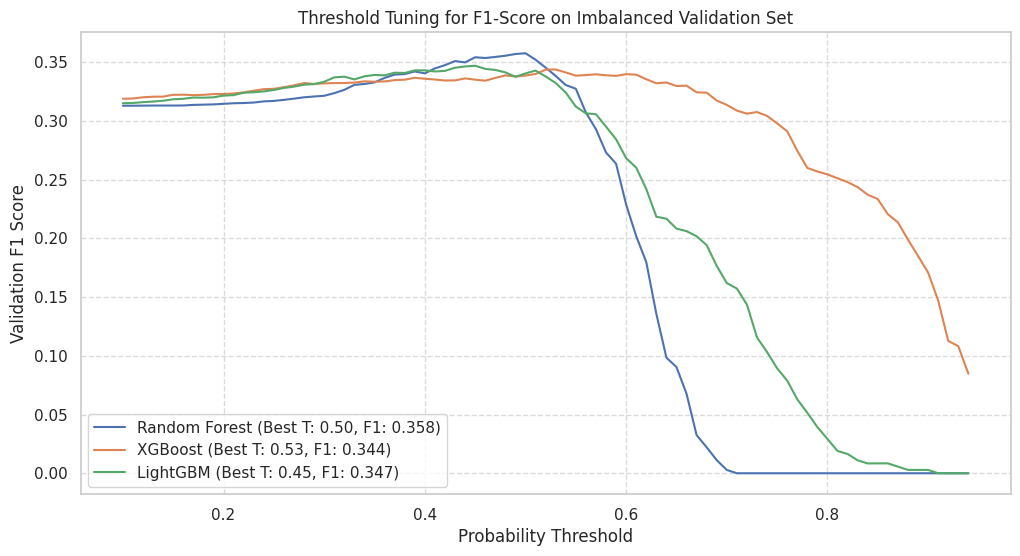

Optimal Thresholds:
  Random Forest: 0.50 (Val F1 = 0.358)
  XGBoost: 0.53 (Val F1 = 0.344)
  LightGBM: 0.45 (Val F1 = 0.347)


In [ ]:
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

models = {'Random Forest': champ_rf, 'XGBoost': champ_xgb, 'LightGBM': champ_lgb}
optimal_thresholds = {}

plt.figure(figsize=(12, 6))

for name, model in models.items():
    # Get probabilities on the validation set
    y_val_probs = model.predict_proba(X_val_final)[:, 1]

    thresholds = np.arange(0.1, 0.95, 0.01)
    f1_scores = []

    for t in thresholds:
        y_val_pred_t = (y_val_probs >= t).astype(int)
        f1_scores.append(f1_score(y_val_1d, y_val_pred_t, zero_division=0))

    # Identify the best threshold for this model
    best_t_idx = np.argmax(f1_scores)
    best_t = thresholds[best_t_idx]
    best_f1 = f1_scores[best_t_idx]
    optimal_thresholds[name] = (best_t, best_f1)

    plt.plot(thresholds, f1_scores, label=f"{name} (Best T: {best_t:.2f}, F1: {best_f1:.3f})")

plt.title("Threshold Tuning for F1-Score on Imbalanced Validation Set")
plt.xlabel("Probability Threshold")
plt.ylabel("Validation F1 Score")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("Optimal Thresholds:")
for name, (t, f1) in optimal_thresholds.items():
    print(f"  {name}: {t:.2f} (Val F1 = {f1:.3f})")

### Step 4: Final Evaluation on the Unseen Test Set
Now, select the single model that performed best on the validation set above. We will apply it, along with its optimal threshold, to the purely unseen test set to report our final, unbiased metrics.

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, precision_score, recall_score

# --- Select your overall best model here ---
FINAL_MODEL_NAME = 'Random Forest' # Change to 'Random Forest' or 'XGBoost' if they performed better
final_model = models[FINAL_MODEL_NAME]
optimal_t = optimal_thresholds[FINAL_MODEL_NAME][0]

# Prepare Test Data (Clean column names and Impute)
X_test_clean = X_test_binary.copy()
X_test_clean.columns = [re.sub(r'[^\w\s]', '', col) for col in X_test_clean.columns]
X_test_final = final_imputer.transform(X_test_clean)

y_test_1d = np.ravel(y_test_binary)

# Predict Probabilities
y_test_probs = final_model.predict_proba(X_test_final)[:, 1]

# Apply the Custom Optimal Threshold
y_test_preds = (y_test_probs >= optimal_t).astype(int)

# Calculate Metrics
test_roc_auc = roc_auc_score(y_test_1d, y_test_probs)
test_pr_auc = average_precision_score(y_test_1d, y_test_probs)
test_f1 = f1_score(y_test_1d, y_test_preds, zero_division=0)
test_prec = precision_score(y_test_1d, y_test_preds, zero_division=0)
test_rec = recall_score(y_test_1d, y_test_preds, zero_division=0)

print(f"--- Final Test Results for {FINAL_MODEL_NAME} (Threshold: {optimal_t:.2f}) ---")
print(f"ROC-AUC:           {test_roc_auc:.4f}")
print(f"PR-AUC (Avg Prec): {test_pr_auc:.4f}")
print(f"F1 Score:          {test_f1:.4f}")
print(f"Precision:         {test_prec:.4f}")
print(f"Recall:            {test_rec:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_1d, y_test_preds))

--- Final Test Results for Random Forest (Threshold: 0.50) ---
ROC-AUC:           0.6427
PR-AUC (Avg Prec): 0.2469
F1 Score:          0.3305
Precision:         0.2216
Recall:            0.6496

Confusion Matrix:
[[2163 1777]
 [ 273  506]]


### Step 4.1: Error Analysis (Deep Dive into False Positives)
Let's investigate the 1777 False Positives to see if there is a tactical pattern causing the model to "cry wolf". We will compare them against True Positives and True Negatives.

Isolated 1777 False Positives for analysis.

--- Average Feature Values by Prediction Outcome ---


prediction_type,"False Positive (Predicted Success, Failed)","True Negative (Predicted Fail, Failed)","True Positive (Predicted Success, Succeeded)"
n_pressers,2.073157,1.495146,2.138340
def_line_height,21.808253,15.402453,22.440109
dist_to_goal_line,25.689994,37.396884,26.132213
area_ratio,0.793820,0.617170,0.794476
speed_differential,-5.541295,-5.534040,-5.413444
trap_intensity,0.046320,0.026792,0.058926


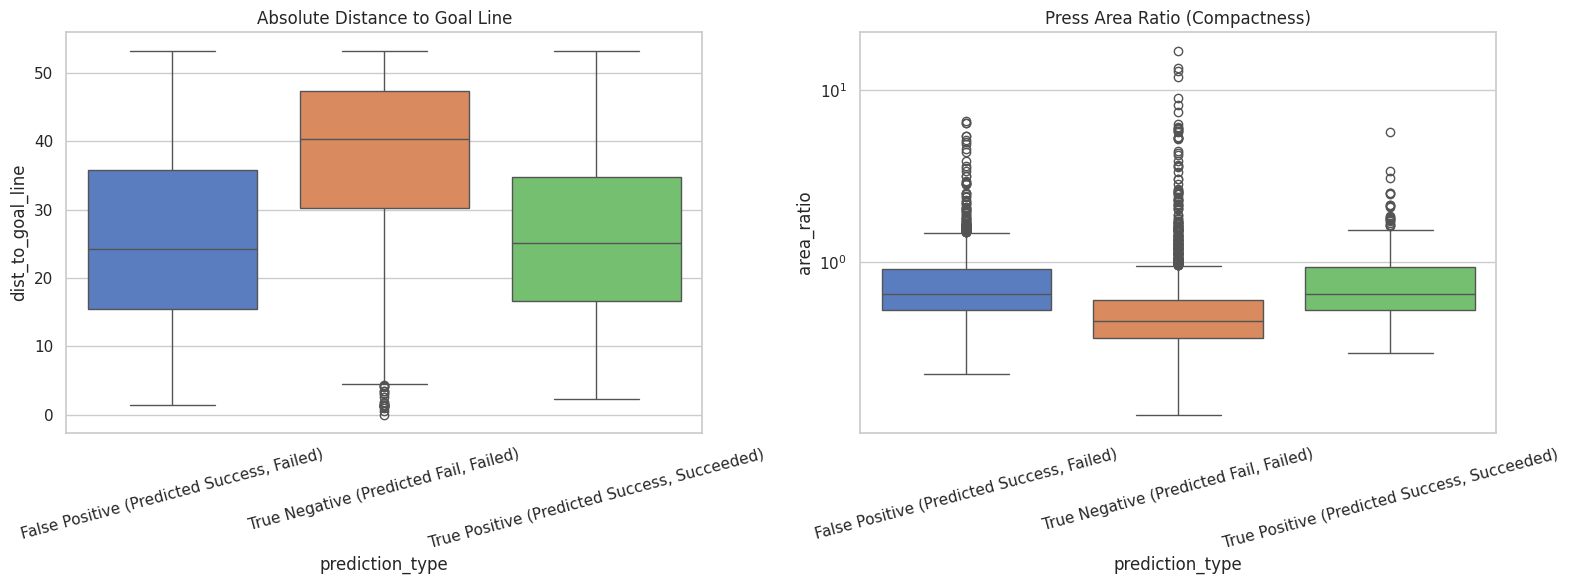

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create masks for the confusion matrix quadrants
fp_mask = (y_test_1d == 0) & (y_test_preds == 1)
tn_mask = (y_test_1d == 0) & (y_test_preds == 0)
tp_mask = (y_test_1d == 1) & (y_test_preds == 1)

# 2. Add prediction results to a copy of the test dataframe
analysis_df = test_df.copy()
analysis_df['prediction_type'] = 'Unknown'
analysis_df.loc[fp_mask, 'prediction_type'] = 'False Positive (Predicted Success, Failed)'
analysis_df.loc[tn_mask, 'prediction_type'] = 'True Negative (Predicted Fail, Failed)'
analysis_df.loc[tp_mask, 'prediction_type'] = 'True Positive (Predicted Success, Succeeded)'

fp_df = analysis_df[fp_mask]
print(f"Isolated {len(fp_df)} False Positives for analysis.\n")

# 3. Compare top tactical features across these groups
features_to_compare = [
    'n_pressers', 'def_line_height', 'dist_to_goal_line',
    'area_ratio', 'speed_differential', 'trap_intensity'
]

# Calculate means for quick tabular comparison
comparison_df = analysis_df[analysis_df['prediction_type'] != 'Unknown'].groupby('prediction_type')[features_to_compare].mean().T
print("--- Average Feature Values by Prediction Outcome ---")
display(comparison_df)

# 4. Plot distributions to visualize the overlaps
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=analysis_df[analysis_df['prediction_type'] != 'Unknown'],
            x='prediction_type', y='dist_to_goal_line', ax=axes[0], palette='muted')
axes[0].set_title('Absolute Distance to Goal Line')
axes[0].tick_params(axis='x', rotation=15)

sns.boxplot(data=analysis_df[analysis_df['prediction_type'] != 'Unknown'],
            x='prediction_type', y='area_ratio', ax=axes[1], palette='muted')
axes[1].set_title('Press Area Ratio (Compactness)')
axes[1].set_yscale('log') # Log scale helps handle extreme ratio outliers
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


### Step 4.2: Built-in Feature Importance
Let's extract the native feature importances from our best model to see which variables contributed the most to the splits.

Extracting built-in feature importances from Random Forest...

--- Top 15 Features by Importance ---


,Feature,Importance
2,mean_speed,0.040008
17,def_line_height,0.039042
3,total_closing,0.037124
20,dist_nearest_2,0.034224
21,dist_nearest_3,0.033158
37,dist_to_goal_line,0.031983
10,team_length,0.031474
30,pressing_intensity,0.031240
4,mean_angle,0.031219
34,area_ratio,0.029525


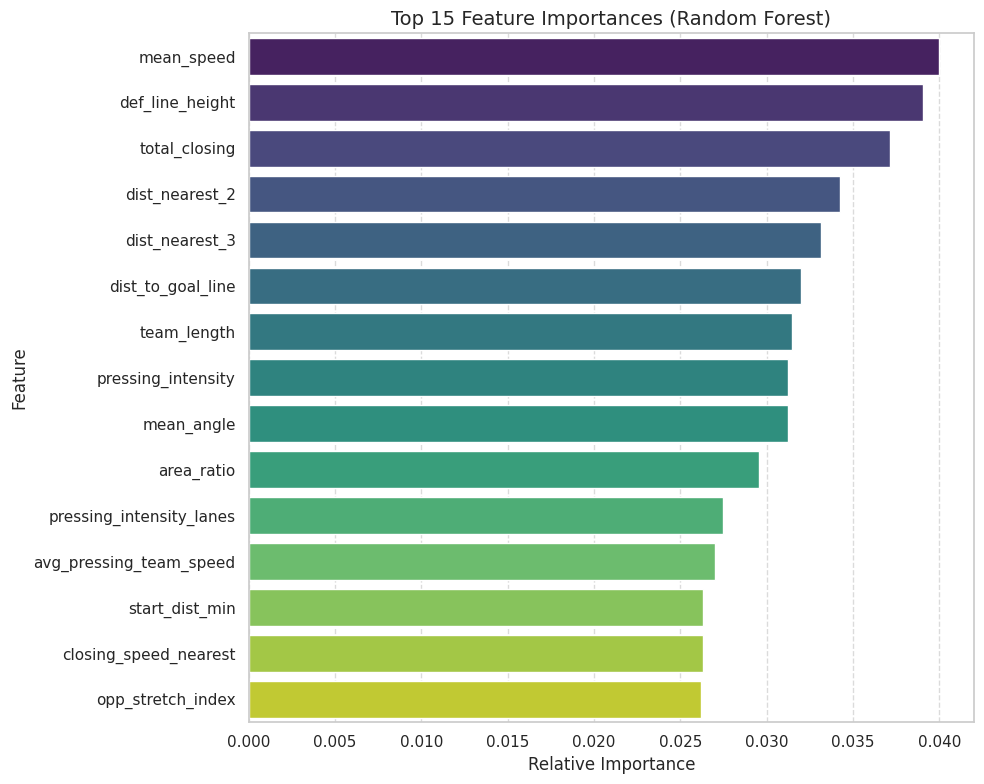

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the final model has the feature_importances_ attribute
if hasattr(final_model, 'feature_importances_'):
    print(f"Extracting built-in feature importances from {FINAL_MODEL_NAME}...")

    # Get feature importances
    importances = final_model.feature_importances_

    # Create a DataFrame for visualization
    importance_df = pd.DataFrame({
        'Feature': X_test_clean.columns,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    # Display the top 15 features in a table
    print("\n--- Top 15 Features by Importance ---")
    display(importance_df.head(15))

    # Plot the top 15 features
    plt.figure(figsize=(10, 8))
    sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='viridis')
    plt.title(f'Top 15 Feature Importances ({FINAL_MODEL_NAME})', fontsize=14)
    plt.xlabel('Relative Importance', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print(f"{FINAL_MODEL_NAME} does not support built-in feature_importances_. Refer to the SHAP values below instead.")

### Step 5: Interpretation (SHAP values)
Finally, let's understand *why* the champion model makes its decisions. SHAP (SHapley Additive exPlanations) values will reveal which features (e.g., number of pressers, defense line height) most strongly influence the likelihood of a successful press.

Calculating SHAP values for Random Forest...


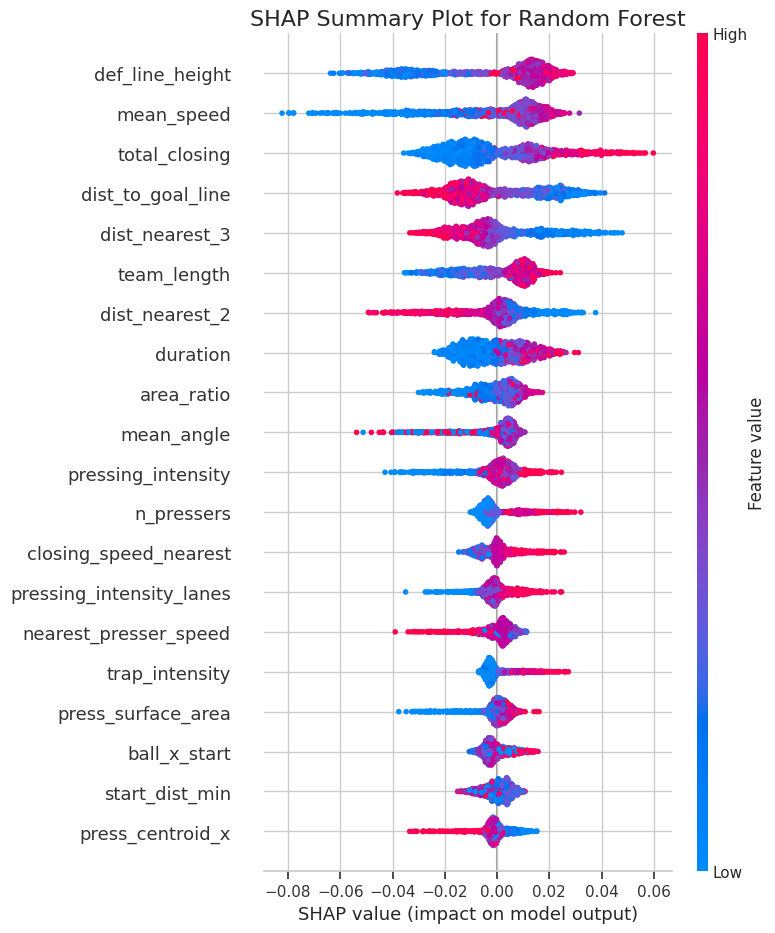


--- Top 10 Most Important Features (by Mean Absolute SHAP) ---
          Feature  Mean Abs SHAP
  def_line_height       0.019422
       mean_speed       0.015898
    total_closing       0.015378
dist_to_goal_line       0.015123
   dist_nearest_3       0.011582
      team_length       0.010649
   dist_nearest_2       0.009771
         duration       0.009177
       area_ratio       0.006566
       mean_angle       0.006527


In [20]:
import shap
import warnings
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore", message=".*is_sparse.*")

print(f"Calculating SHAP values for {FINAL_MODEL_NAME}...")

# Use a random sample of the test set to speed up SHAP calculation
X_test_sample = shap.utils.sample(X_test_final, 1500, random_state=42)

# Create the explainer using the final trained model
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_sample)

# Plot the summary plot
plt.figure(figsize=(10, 8))
plt.title(f"SHAP Summary Plot for {FINAL_MODEL_NAME}", fontsize=16)

# Handle different SHAP output formats (RF/LGBM vs XGB)
if isinstance(shap_values, list):
    # Random Forest / LightGBM returns list [class_0_shap, class_1_shap]
    shap_vals_class1 = shap_values[1]
elif len(np.shape(shap_values)) == 3:
    shap_vals_class1 = shap_values[:,:,1]
else:
    # XGBoost usually returns just class 1
    shap_vals_class1 = shap_values

shap.summary_plot(shap_vals_class1, X_test_sample, show=False)

plt.tight_layout()
plt.show()

# Calculate mean absolute SHAP values per feature
mean_abs_shap = np.mean(np.abs(shap_vals_class1), axis=0)

# Create a DataFrame to sort and display
shap_df = pd.DataFrame({
    'Feature': X_test_sample.columns,
    'Mean Abs SHAP': mean_abs_shap
})

shap_df = shap_df.sort_values(by='Mean Abs SHAP', ascending=False)

print("\n--- Top 10 Most Important Features (by Mean Absolute SHAP) ---")
print(shap_df.head(10).to_string(index=False))

In [ ]:
# Print the full list of features used in the model
features_list = X_train_binary.columns.tolist()

print(f"Total features used for training: {len(features_list)}\n")
print("Feature List:")
for i, col in enumerate(features_list, 1):
    print(f"{i:2}. {col}")